# Tarea 1 Inteligencia Artificial
**Estudiantes**: Fernando Ortega e Ihan San Martin

#### Declaración de uso de Inteligencia Artificial
En esta tarea se utilizó la Inteligencia Artificial como asistencia para sintáxis de las distintas librerías y módulos python que se utilizaron, depuración de errores y generación de visualizaciones de las redes, las cuales eran opcionales y no salen en la rúbrica. La IA **NO** fue utilizada para el diseño de las soluciones ni la interpretación de los resultados obtenidos.

# Actividad 1
**Dataset**: Airline Passanger Satisfaction, cuenta con 100 mil datos y más de 12 columnas útiles, para la actividad se utilizaron 12 columnas útiles. El dataset original se puede encontrar en **Kaggle**.

## Red Bayesiana Inicial Sin Aprendizaje

In [1]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork

red_inicial = DiscreteBayesianNetwork([
    
    ('Customer Type', 'Type of Travel'),
    ('Customer Type', 'Ease of Online booking'),
    ('Customer Type', 'Checkin service'),

    ('Type of Travel', 'Class'),

    ('Class', 'Inflight wifi service'),
    ('Class', 'Seat comfort'),
    ('Class', 'Food and drink'),
    ('Class', 'Inflight entertainment'),
    ('Class', 'Cleanliness'),
    ('Class', 'Baggage handling'),

    ('Ease of Online booking', 'satisfaction'),
    ('Checkin service', 'satisfaction'),
    ('Inflight wifi service', 'satisfaction'),
    ('Seat comfort', 'satisfaction'),
    ('Food and drink', 'satisfaction'),
    ('Inflight entertainment', 'satisfaction'),
    ('Cleanliness', 'satisfaction'),
    ('Baggage handling', 'satisfaction'),
    
])

print("Nodos:", red_inicial.nodes())

Nodos: ['Customer Type', 'Type of Travel', 'Ease of Online booking', 'Checkin service', 'Class', 'Inflight wifi service', 'Seat comfort', 'Food and drink', 'Inflight entertainment', 'Cleanliness', 'Baggage handling', 'satisfaction']


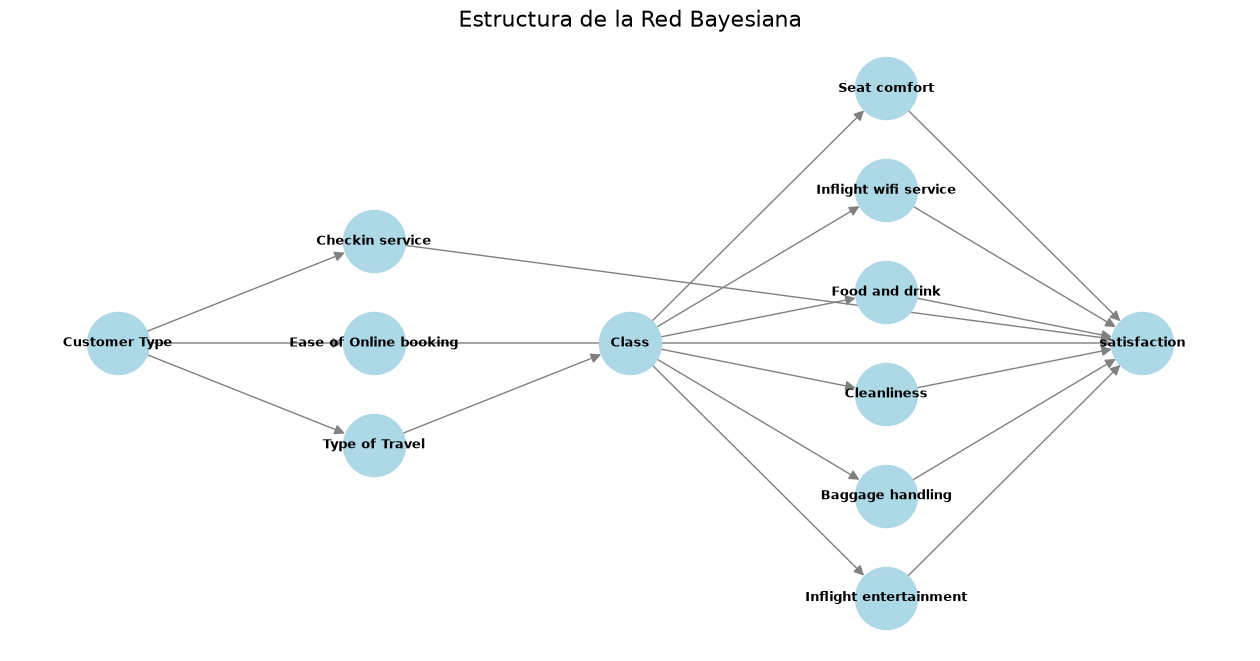

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
G = nx.DiGraph(red_inicial.edges())

niveles = {
    'Customer Type': 0, 'Type of Travel': 1, 'Checkin service': 1, 'Ease of Online booking': 1,
    'Class': 2, 'Baggage handling': 3,
    'Inflight wifi service': 3, 'Seat comfort': 3, 'Food and drink': 3, 'Cleanliness': 3, 'Inflight entertainment': 3,
    'satisfaction': 4
}
nx.set_node_attributes(G, niveles, 'layer')

posiciones = nx.multipartite_layout(G, subset_key='layer')

nx.draw_networkx(
    G, pos=posiciones, node_size=2000, node_color='lightblue', 
    edge_color='gray', font_size=9, font_weight='bold', arrows=True, arrowsize=15
)

plt.title("Estructura de la Red Bayesiana", fontsize=16)
plt.axis('off')
plt.show()

**Variable Objetivo: Satisfacción**\
La satisfacción es la variable objetivo que se estudia en la primera actividad de la tarea, esta depende directamente de los distintos servicios que ofrecen las aerolineas que definen la experiencia final del usuario, y este le pone una calificación del 0 al 5 posteriormente. 

**Características de Calidad de Servicio**\
La mayoría de las carácterísticas de servicio dependen de la clase del vuelo, ya sea clase business, eco (economy) o eco plus, ya que definen el presupuesto que infiere en la calidad de las características.

**Clase de Vuelo**\
La clase depende directamente del tipo de vuelo que se vaya a tomar (business o personal), porque ese objetivo del vuelo afecta a que "tantas" comodidades quiere el cliente al momento de viajar.

**Características pre-vuelo y Tipo de Vuelo**\
Las únicas dos características que no dependen de la clase son el servicio de checkin y la facilidad de compra online, estos dependen del tipo de cliente ya que si es un cliente leal o no leal va a depender en qué tanto conoce el sistema y si se le hará más a meno todo el proceso.Luego tenemos el tipo de vuelo (Travel type) que igual depende del tipo de cliente, ya que si no es leal a la aerolinea puede no estar de acuerdo con pagar el vuelo más caro.

**Tipo de Cliente**\
Finalmente tenemos el tipo de cliente que no depende de ninguna otra variable ya que es el inicio de todo el proceso de tomar un vuelo, una persona quiere viajar y lo primero que se observa es si es un cliente leal o desleal.

# Ejecución de Inferencias

In [3]:
from pgmpy.inference import VariableElimination

df_limpio = pd.read_csv('aerolinea_limpio.csv')

red_inicial.fit(df_limpio)

infer = VariableElimination(red_inicial)


print("\n Inferencia 1 (Probabilidad de estar satisfecho en clase Economy y pésimo wifi)")
inf_1 = infer.query(variables=['satisfaction'], evidence={'Class': 'Eco', 'Inflight wifi service': 1})
print(inf_1)

print("\n Inferencia 2 (Probabilidad por clase cuando el viaje es tipo business)")
inf_2 = infer.query(variables=['Class'], evidence={'Type of Travel': 'Business travel'})
print(inf_2)

print("\n Inferencia 3 (Probabilidad por tipo de cliente cuando la satisfacción es neutral o insatisfecho y la limpieza es mala)")
inf_3 = infer.query(variables=['Customer Type'], evidence={'satisfaction': 'neutral or dissatisfied', 'Cleanliness': 1})
print(inf_3)

/home/fernando/Universidad/ia-tarea1/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (



 Inferencia 1 (Probabilidad de estar satisfecho en clase Economy y pésimo wifi)
+---------------------------------------+---------------------+
| satisfaction                          |   phi(satisfaction) |
+=======================================+=====================+
| satisfaction(neutral or dissatisfied) |              0.5003 |
+---------------------------------------+---------------------+
| satisfaction(satisfied)               |              0.4997 |
+---------------------------------------+---------------------+

 Inferencia 2 (Probabilidad por clase cuando el viaje es tipo business)
+-----------------+--------------+
| Class           |   phi(Class) |
+=================+==============+
| Class(Business) |       0.6600 |
+-----------------+--------------+
| Class(Eco)      |       0.2852 |
+-----------------+--------------+
| Class(Eco Plus) |       0.0548 |
+-----------------+--------------+

 Inferencia 3 (Probabilidad por tipo de cliente cuando la satisfacción es neutral 

**Inferencia 1**\
Esta inferencia responde a la pregunta $P(satisfaction | class=Eco, wifi=1)$, los resultados fueron 50.03% para "neutral o insatisfecho" y 49.97% para "satisfecho", es practicamente un empate, por lo que se puede decir que la clase Economy tiene una buena relación calidad precio, y por otro lado, la calidad del Wifi no es algo que afecte inmensamente a la experiencia del viaje.

**Inferencia 2**\
$P(Class | TypeOfTravel=Business)$, en este caso la clase Business gana con un 66% de probabilidad, luego sigue Economy con un 28.52% y por último Economy Plus con un 5.48%, es un resultado evidente ya que el tipo de viaje es business, por lo que la clase más probable es la business.

**Inferencia 3**\
$P(CustomerType|satisfaction=neutralOrDissatisfied,Cleanliness=1)$ El cliente leal tiene la posibilidad más grande en esta distribución con un 83.36%, por otro lado el cliente desleal tiene un 16.64% de posibilidad. Esta distribución significa que si un cliente está insatisfecho con su experiencia y calificó la limpieza como mala, lo más probable es que sea un cliente leal, esto puede ser debido a que un cliente leal es más suceptible a estar decepcionado de la aerolinea en la cual viaja tanto cuando siente que una característica de calidad de servicio no está a la misma altura que otras ocasiones.

# Generación de Red Aprendida

In [4]:
from pgmpy.causal_discovery import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork

columnas_red = list(red_inicial.nodes())
df_estructura = df_limpio[columnas_red]

hc = HillClimbSearch(scoring_method="bic-d");
hc.fit(df_estructura)

dag_aprendido = hc.causal_graph_
dag_sin_ciclos = dag_aprendido.to_dag();
print("aristas:", dag_sin_ciclos.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

aristas: [('Customer Type', 'Inflight wifi service'), ('Customer Type', 'Class'), ('Customer Type', 'Cleanliness'), ('Customer Type', 'Ease of Online booking'), ('Customer Type', 'satisfaction'), ('Customer Type', 'Type of Travel'), ('Customer Type', 'Seat comfort'), ('Customer Type', 'Baggage handling'), ('Inflight wifi service', 'satisfaction'), ('Inflight wifi service', 'Type of Travel'), ('Ease of Online booking', 'Type of Travel'), ('Ease of Online booking', 'Inflight wifi service'), ('Class', 'Ease of Online booking'), ('Class', 'Cleanliness'), ('Class', 'satisfaction'), ('Class', 'Type of Travel'), ('satisfaction', 'Food and drink'), ('satisfaction', 'Type of Travel'), ('Cleanliness', 'Food and drink'), ('Cleanliness', 'Inflight entertainment'), ('Seat comfort', 'Class'), ('Seat comfort', 'Cleanliness'), ('Seat comfort', 'Inflight entertainment'), ('Inflight entertainment', 'Inflight wifi service'), ('Inflight entertainment', 'satisfaction'), ('Inflight entertainment', 'Food and

In [5]:
red_aprendida = DiscreteBayesianNetwork()
red_aprendida.add_nodes_from(dag_sin_ciclos.nodes)
red_aprendida.add_edges_from(dag_sin_ciclos.edges)

print("nodos:", red_aprendida.nodes())

nodos: ['Customer Type', 'Inflight wifi service', 'Ease of Online booking', 'Class', 'satisfaction', 'Type of Travel', 'Cleanliness', 'Food and drink', 'Seat comfort', 'Inflight entertainment', 'Baggage handling', 'Checkin service']


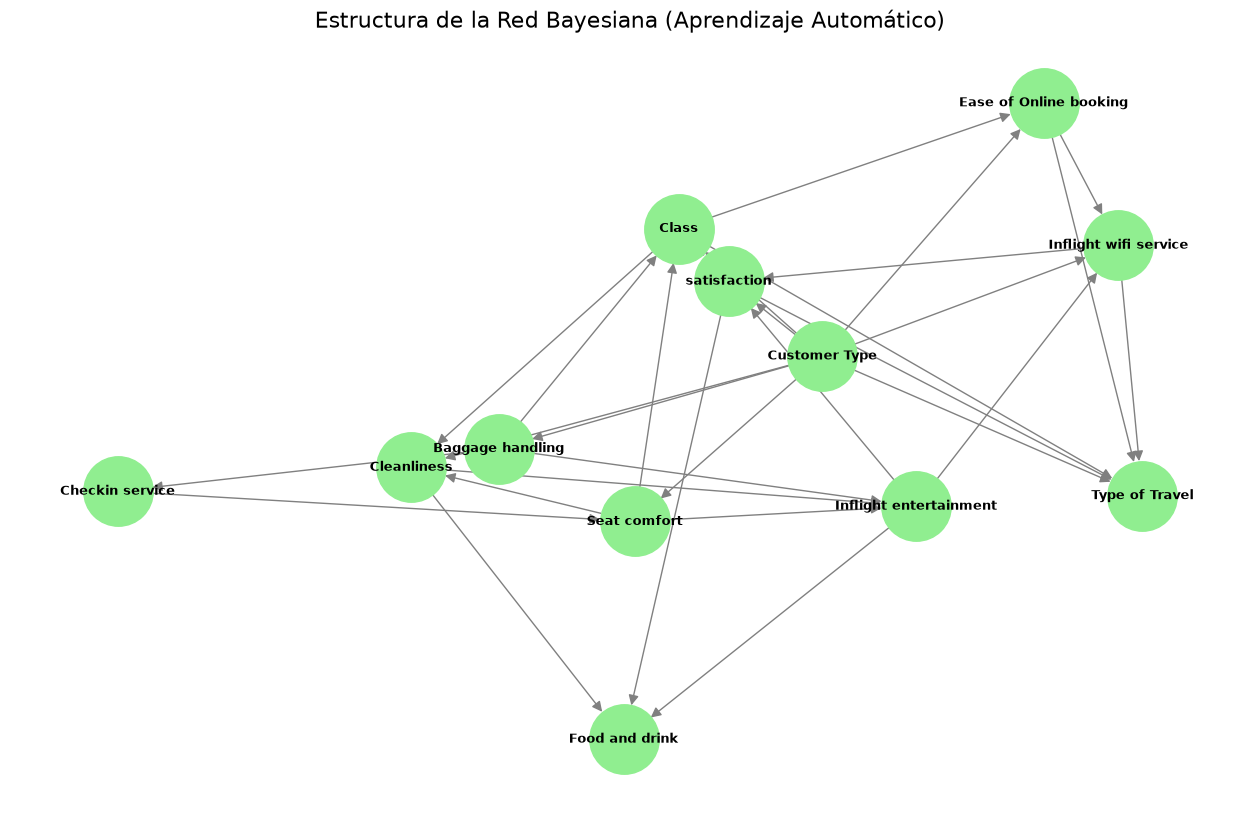

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))

G_auto = nx.DiGraph(red_aprendida.edges())

posiciones_auto = nx.spring_layout(G_auto, seed=42, k=0.9) 

nx.draw_networkx(
    G_auto, 
    pos=posiciones_auto, 
    node_size=2500, 
    node_color='lightgreen',
    edge_color='gray', 
    font_size=9, 
    font_weight='bold', 
    arrows=True,
    arrowsize=15
)

plt.title("Estructura de la Red Bayesiana (Aprendizaje Automático)", fontsize=16)
plt.axis('off')
plt.show()

# Ejecución de Inferencias con Segunda Estructura

In [7]:
from pgmpy.inference import VariableElimination

red_aprendida.fit(df_estructura)

infer_aprendida = VariableElimination(red_aprendida)

print("\n Inferencia 1 (Probabilidad de estar satisfecho en clase Economy y pésimo wifi)")
inf_4 = infer_aprendida.query(variables=['satisfaction'], evidence={'Class': 'Eco', 'Inflight wifi service': 1})
print(inf_4)

print("\n Inferencia 2 (Probabilidad por clase cuando el viaje es tipo business)")
inf_5 = infer_aprendida.query(variables=['Class'], evidence={'Type of Travel': 'Business travel'})
print(inf_5)

print("\n Inferencia 3 (Probabilidad por tipo de cliente cuando la satisfacción es neutral o insatisfecho y la limpieza es mala)")
inf_6 = infer_aprendida.query(variables=['Customer Type'], evidence={'satisfaction': 'neutral or dissatisfied', 'Cleanliness': 1})
print(inf_6)


 Inferencia 1 (Probabilidad de estar satisfecho en clase Economy y pésimo wifi)
+---------------------------------------+---------------------+
| satisfaction                          |   phi(satisfaction) |
+=======================================+=====================+
| satisfaction(neutral or dissatisfied) |              1.0000 |
+---------------------------------------+---------------------+
| satisfaction(satisfied)               |              0.0000 |
+---------------------------------------+---------------------+

 Inferencia 2 (Probabilidad por clase cuando el viaje es tipo business)
+-----------------+--------------+
| Class           |   phi(Class) |
+=================+==============+
| Class(Business) |       0.6528 |
+-----------------+--------------+
| Class(Eco)      |       0.2977 |
+-----------------+--------------+
| Class(Eco Plus) |       0.0495 |
+-----------------+--------------+

 Inferencia 3 (Probabilidad por tipo de cliente cuando la satisfacción es neutral 

**Inferencia 1**\
En esta inferencia se vio la mayor diferencia con respecto a las hechas con la red bayesiana construida manualmente, la probabilidad de que un cliente esté neutro o insatisfecho, dado que viajó en clase Economy y además el servicio de Wifi ha sido pésimo es del 100%, es un resultado interesante aunque no tiene tanto sentido que tenga el 100% ya que como se dijo antes, el wifi no es una característica primordial en la calidad de un viaje por lo que algunos pasajeros satisfechos deben haber.

**Inferencia 2**\
Esta está muy cercana a lo que se obtuvo con la red anterior, la probabilidad de que el viaje sea en clase business dado que el tipo de viaje es de negocios (business) es del 65.66% contra el 66% anterior, la probabilidad de la clase Eco es de 29.45% contra el 28.52% anterior, y la probabilidad de la clase Eco plus es de 4.89% contra el 5.48% anterior. Los resultados son muy parecidos a los anteriores, así que el análisis e interpretación es similar, si el tipo de viaje será de negocios, lo más probable es que la clase elegida sea la Business, en vez de la Eco y Eco plus, lo cual tiene sentido lógico.

**Inferencia 3**\
La probabilidad de que un cliente sea leal dado que su satisfacción ha sido neutral o insatisfecho y su calificación de la limpieza es 1, es del 73.88% contra el 83.36% anterior y la probabilidad de que el cliente sea desleal dado las mismas condiciones, es de un 26.12% contra el 16.64% anterior. Los resultados no están muy lejos de los anteriores pero esta distribución es más realista, ya que si bien, lo más posible es que un cliente leal se sienta más decepcionado que uno desleal, en un dataset de 100 mil datos hay más variación, por lo que tiene sentido que la probabilidad de clientes desleales haya subido.

# Comparación de Ambas Estructuras

La primera diferencia grande que se puede apreciar es en la estructura de la red, es que en la hecha manualmente no hay tantas conexiones, ya que se pensó en una estructura básica y lógica humanamanete, en cambio la segunda estructura tiene muchas más conexiones, esto debe ser porque al ser la computadora tiene más capacidad de procesamiento y algunas conexiones que para nosotros pueden ser innecesarias, para una máquina pueden ser más útiles para cálcular probabilidades más precisamente.

Luego se en el análisis de las inferencias se pudieron ver tanto similitudes como diferencias más grandes, lo que da a entender que la estructura manual no estaba mal estructurada. Por ejemplo en la inferencia 1 el resultado no fue muy lógico para nosotros pero tal vez con más entrenamiento empieza a cobrar más sentido y tener más precisión, por otro lado las inferencias 2 y 3 son más similares a lo que se pensó con lógica humana y hacen que las interpretaciones iniciales tuvieran más sentido y se consideren más precisas.

# Actividad 2

## 2a) Estados, observaciones y separación de datos

En esta actividad trabajamos con el dataset `energydata_complete.csv`, que trae mediciones de una casa cada 10 minutos. La idea general es estudiar cómo va cambiando el consumo de energía en el tiempo, primero con cadenas de Markov y después con HMM.

Para esta letra todavía no armamos los modelos como tal. Lo que hicimos fue preparar los datos: definir los estados de consumo, definir las observaciones que después va a usar el HMM y separar los datos en entrenamiento y evaluación.

Primero cargamos el archivo y ordenamos todo por fecha. Esto lo hicimos porque el orden importa mucho en esta parte: no estamos trabajando con datos independientes cualquiera, sino con una serie temporal. Si mezcláramos las filas al azar, se perdería la idea de que un estado viene después de otro.

También calculamos los dos índices que pide el enunciado. Para temperatura usamos el promedio de las tres primeras temperaturas de la casa:

$$I_{temperatura} = \frac{T1 + T2 + T3}{3}$$

Y para humedad hicimos lo mismo, pero con las tres primeras humedades relativas:

$$I_{humedad} = \frac{RH_1 + RH_2 + RH_3}{3}$$

Decidimos usar exactamente esas columnas porque son las que pide el enunciado, y además representan una especie de resumen simple de las condiciones internas de la casa.

In [8]:
import pandas as pd

df_energy = pd.read_csv('energydata_complete.csv')
df_energy['date'] = pd.to_datetime(df_energy['date'])
df_energy = df_energy.sort_values('date').reset_index(drop=True)

df_energy['I_temperatura'] = (df_energy['T1'] + df_energy['T2'] + df_energy['T3']) / 3
df_energy['I_humedad'] = (df_energy['RH_1'] + df_energy['RH_2'] + df_energy['RH_3']) / 3

df_energy.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,I_temperatura,I_humedad
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,19.626667,45.705556
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,19.626667,45.401944
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,19.626667,45.286667
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,19.626667,45.218889
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,19.626667,45.287778


Después definimos los seis estados de consumo para Appliances. Estos estados son los que después se van a usar como estados de la cadena de Markov y también como estados ocultos del HMM.

Los estados son:

- muy bajo
- bajo
- medio-bajo
- medio-alto
- alto
- muy alto

Para separarlos decidimos usar cuantiles. Ordenamos los consumos y los partimos en seis grupos de tamaño parecido. Usamos este criterio porque en este dataset casi todo el consumo está concentrado en valores bajos, pero igual existen algunos peaks altos. Si usábamos cortes inventados a mano, podía pasar que algunos estados quedaran casi vacíos.

In [9]:
estados_consumo = ['muy bajo', 'bajo', 'medio-bajo', 'medio-alto', 'alto', 'muy alto']
niveles = ['bajo', 'medio', 'alto']

corte = int(len(df_energy) * 0.8)
df_train = df_energy.iloc[:corte].copy()
df_eval = df_energy.iloc[corte:].copy()

cortes_consumo = df_train['Appliances'].quantile([1/6, 2/6, 3/6, 4/6, 5/6]).values
cortes_temp = df_train['I_temperatura'].quantile([1/3, 2/3]).values
cortes_humedad = df_train['I_humedad'].quantile([1/3, 2/3]).values

print('Cortes de Appliances:', cortes_consumo)
print('Cortes de temperatura:', cortes_temp)
print('Cortes de humedad:', cortes_humedad)

Cortes de Appliances: [ 40.  50.  60.  80. 120.]
Cortes de temperatura: [20.34777778 21.36333333]
Cortes de humedad: [38.33       41.38888889]


Algo importante es que calculamos los cortes usando solo el conjunto de entrenamiento. Esto lo hicimos para no mirar la evaluación antes de tiempo. En el fondo, la evaluación debería simular datos futuros que el modelo todavía no conoce.

La separación fue cronológica: dejamos el primer 80% para entrenamiento y el último 20% para evaluación. No lo hicimos aleatorio porque la actividad trata de evolución temporal.

In [10]:
print('Total de registros:', len(df_energy))
print('Registros de entrenamiento:', len(df_train))
print('Registros de evaluación:', len(df_eval))
print('Fecha inicial:', df_energy['date'].min())
print('Fecha final:', df_energy['date'].max())

Total de registros: 19735
Registros de entrenamiento: 15788
Registros de evaluación: 3947
Fecha inicial: 2016-01-11 17:00:00
Fecha final: 2016-05-27 18:00:00


Luego discretizamos las variables. Para Appliances usamos los seis estados de consumo. Para I_temperatura y I_humedad usamos tres niveles: bajo, medio y alto. En el caso de lights, decidimos separarlo de forma más directa, porque la variable viene en valores como 0, 10, 20, 30, etc. Entonces usamos:

- apagada cuando lights es 0.
- consumo bajo cuando está entre 10 y 20.
- consumo alto cuando es 30 o más.

Lo separamos así porque si lights vale 0 no hay luces prendidas, y cuando ya llega a 30 o más asumimos que el gasto en luces es más alto.

In [11]:
def discretizar_datos(df):
    df = df.copy()

    df['estado_consumo'] = pd.cut(
        df['Appliances'],
        bins=[-float('inf')] + list(cortes_consumo) + [float('inf')],
        labels=estados_consumo,
        include_lowest=True
    )

    df['nivel_temperatura'] = pd.cut(
        df['I_temperatura'],
        bins=[-float('inf')] + list(cortes_temp) + [float('inf')],
        labels=niveles,
        include_lowest=True
    )

    df['nivel_humedad'] = pd.cut(
        df['I_humedad'],
        bins=[-float('inf')] + list(cortes_humedad) + [float('inf')],
        labels=niveles,
        include_lowest=True
    )

    df['nivel_luces'] = pd.cut(
        df['lights'],
        bins=[-float('inf'), 0, 20, float('inf')],
        labels=['apagada', 'consumo bajo', 'consumo alto'],
        include_lowest=True
    )

    df['observacion'] = (
        df['nivel_luces'].astype(str) + ' | temp ' +
        df['nivel_temperatura'].astype(str) + ' | humedad ' +
        df['nivel_humedad'].astype(str)
    )

    return df

train_2a = discretizar_datos(df_train)
eval_2a = discretizar_datos(df_eval)
df_2a = pd.concat([train_2a, eval_2a]).sort_values('date').reset_index(drop=True)

train_2a[['date', 'Appliances', 'estado_consumo', 'lights', 'nivel_luces', 'I_temperatura', 'nivel_temperatura', 'I_humedad', 'nivel_humedad', 'observacion']].head()

,date,Appliances,estado_consumo,lights,nivel_luces,I_temperatura,nivel_temperatura,I_humedad,nivel_humedad,observacion
0,2016-01-11 17:00:00,60,medio-bajo,30,consumo alto,19.626667,bajo,45.705556,alto,consumo alto | temp bajo | humedad alto
1,2016-01-11 17:10:00,60,medio-bajo,30,consumo alto,19.626667,bajo,45.401944,alto,consumo alto | temp bajo | humedad alto
2,2016-01-11 17:20:00,50,bajo,30,consumo alto,19.626667,bajo,45.286667,alto,consumo alto | temp bajo | humedad alto
3,2016-01-11 17:30:00,50,bajo,40,consumo alto,19.626667,bajo,45.218889,alto,consumo alto | temp bajo | humedad alto
4,2016-01-11 17:40:00,60,medio-bajo,40,consumo alto,19.626667,bajo,45.287778,alto,consumo alto | temp bajo | humedad alto


Para las observaciones del HMM combinamos tres cosas: luces, temperatura y humedad. Cada una tiene 3 niveles posibles, por lo tanto el total de observaciones posibles es:

$$3 \times 3 \times 3 = 27$$

O sea, una observación podría ser algo como apagada - temp bajo - humedad alta. Esa observación no nos dice directamente el consumo real de Appliances, pero sí entrega pistas del contexto de la casa. El consumo queda como estado oculto y estas combinaciones quedan como observaciones visibles. Las observaciones posibles son: 


```text
+----+---------------+-------------+---------+------------------------------------------+
| Nº | Luces         | Temperatura | Humedad | Observación                              |
+----+---------------+-------------+---------+------------------------------------------+
| 1  | apagada       | bajo        | bajo    | apagada | temp bajo | humedad bajo       |
| 2  | apagada       | bajo        | medio   | apagada | temp bajo | humedad medio      |
| 3  | apagada       | bajo        | alto    | apagada | temp bajo | humedad alto       |
| 4  | apagada       | medio       | bajo    | apagada | temp medio | humedad bajo      |
| 5  | apagada       | medio       | medio   | apagada | temp medio | humedad medio     |
| 6  | apagada       | medio       | alto    | apagada | temp medio | humedad alto      |
| 7  | apagada       | alto        | bajo    | apagada | temp alto | humedad bajo       |
| 8  | apagada       | alto        | medio   | apagada | temp alto | humedad medio      |
| 9  | apagada       | alto        | alto    | apagada | temp alto | humedad alto       |
| 10 | consumo bajo  | bajo        | bajo    | consumo bajo | temp bajo | humedad bajo  |
| 11 | consumo bajo  | bajo        | medio   | consumo bajo | temp bajo | humedad medio |
| 12 | consumo bajo  | bajo        | alto    | consumo bajo | temp bajo | humedad alto  |
| 13 | consumo bajo  | medio       | bajo    | consumo bajo | temp medio | humedad bajo |
| 14 | consumo bajo  | medio       | medio   | consumo bajo | temp medio | humedad medio |
| 15 | consumo bajo  | medio       | alto    | consumo bajo | temp medio | humedad alto |
| 16 | consumo bajo  | alto        | bajo    | consumo bajo | temp alto | humedad bajo  |
| 17 | consumo bajo  | alto        | medio   | consumo bajo | temp alto | humedad medio |
| 18 | consumo bajo  | alto        | alto    | consumo bajo | temp alto | humedad alto  |
| 19 | consumo alto  | bajo        | bajo    | consumo alto | temp bajo | humedad bajo  |
| 20 | consumo alto  | bajo        | medio   | consumo alto | temp bajo | humedad medio |
| 21 | consumo alto  | bajo        | alto    | consumo alto | temp bajo | humedad alto  |
| 22 | consumo alto  | medio       | bajo    | consumo alto | temp medio | humedad bajo |
| 23 | consumo alto  | medio       | medio   | consumo alto | temp medio | humedad medio |
| 24 | consumo alto  | medio       | alto    | consumo alto | temp medio | humedad alto |
| 25 | consumo alto  | alto        | bajo    | consumo alto | temp alto | humedad bajo  |
| 26 | consumo alto  | alto        | medio   | consumo alto | temp alto | humedad medio |
| 27 | consumo alto  | alto        | alto    | consumo alto | temp alto | humedad alto  |
+----+---------------+-------------+---------+------------------------------------------+
```

In [12]:
observaciones_posibles = []

for luz in ['apagada', 'consumo bajo', 'consumo alto']:
    for temp in niveles:
        for hum in niveles:
            observaciones_posibles.append(luz + ' | temp ' + temp + ' | humedad ' + hum)

print('Cantidad de observaciones posibles:', len(observaciones_posibles))
print()
for obs in observaciones_posibles:
    print('-', obs)

Cantidad de observaciones posibles: 27

- apagada | temp bajo | humedad bajo
- apagada | temp bajo | humedad medio
- apagada | temp bajo | humedad alto
- apagada | temp medio | humedad bajo
- apagada | temp medio | humedad medio
- apagada | temp medio | humedad alto
- apagada | temp alto | humedad bajo
- apagada | temp alto | humedad medio
- apagada | temp alto | humedad alto
- consumo bajo | temp bajo | humedad bajo
- consumo bajo | temp bajo | humedad medio
- consumo bajo | temp bajo | humedad alto
- consumo bajo | temp medio | humedad bajo
- consumo bajo | temp medio | humedad medio
- consumo bajo | temp medio | humedad alto
- consumo bajo | temp alto | humedad bajo
- consumo bajo | temp alto | humedad medio
- consumo bajo | temp alto | humedad alto
- consumo alto | temp bajo | humedad bajo
- consumo alto | temp bajo | humedad medio
- consumo alto | temp bajo | humedad alto
- consumo alto | temp medio | humedad bajo
- consumo alto | temp medio | humedad medio
- consumo alto | temp m

Finalmente revisamos que efectivamente se estén usando los estados y observaciones esperadas. En entrenamiento deberían aparecer los seis estados de consumo, porque los cortes se hicieron con cuantiles. Con las observaciones pueden aparecer hasta 27 combinaciones, aunque no necesariamente todas tienen que aparecer con la misma frecuencia.

En este punto lo importante es que train_2a y eval_2a ya quedan listos para usarlos después en los dos modelos, tanto en la cadena continua como en la cadena diaria.

In [13]:
print('Estados de consumo en entrenamiento:')
print(train_2a['estado_consumo'].value_counts().sort_index())
print()
print('Observaciones distintas en entrenamiento:', train_2a['observacion'].nunique())
print('Observaciones distintas en evaluación:', eval_2a['observacion'].nunique())

Estados de consumo en entrenamiento:
estado_consumo
muy bajo      2888
bajo          3482
medio-bajo    2384
medio-alto    2077
alto          2502
muy alto      2455
Name: count, dtype: int64

Observaciones distintas en entrenamiento: 27
Observaciones distintas en evaluación: 14


## 2b) Cadenas de Markov continua y diaria

En este caso cada instante corresponde a una medición de 10 minutos. Entonces, por ejemplo, si en un momento el consumo está en bajo, queremos contar cuántas veces después se queda en bajo, cuántas veces sube a medio-bajo, cuántas veces baja a muy bajo, etc.

La fórmula que usamos para cada probabilidad de transición fue esta:

$$P(j|i) = \frac{\text{cantidad de veces que pasamos de i a j}}{\text{cantidad total de salidas desde i}}$$

O sea, primero contamos las transiciones y después dividimos cada fila por su total.

Primero hicimos la cadena continua. Acá tomamos todos los registros de entrenamiento como una sola secuencia larga, sin cortar por día.

Esto significa que también cuenta la transición entre el último registro de un día y el primer registro del día siguiente. No necesariamente es perfecto para interpretar una jornada normal, pero sirve para ver el comportamiento general del consumo en toda la serie de tiempo.

In [14]:
import numpy as np

n_estados = len(estados_consumo)
indice_estado = {estado: i for i, estado in enumerate(estados_consumo)}

secuencia_continua = train_2a['estado_consumo'].astype(str).tolist()
conteos_continuo = np.zeros((n_estados, n_estados))

for i in range(len(secuencia_continua) - 1):
    actual = secuencia_continua[i]
    siguiente = secuencia_continua[i + 1]
    fila = indice_estado[actual]
    columna = indice_estado[siguiente]
    conteos_continuo[fila, columna] = conteos_continuo[fila, columna] + 1

matriz_continua = conteos_continuo / conteos_continuo.sum(axis=1, keepdims=True)

matriz_continua_df = pd.DataFrame(matriz_continua, index=estados_consumo, columns=estados_consumo)
matriz_continua_df

,muy bajo,bajo,medio-bajo,medio-alto,alto,muy alto
muy bajo,0.573753,0.302285,0.083795,0.026662,0.005540,0.007964
bajo,0.259621,0.443711,0.225158,0.050546,0.010052,0.010913
medio-bajo,0.104027,0.334312,0.345218,0.171560,0.018876,0.026007
medio-alto,0.026962,0.099663,0.207511,0.431391,0.174771,0.059701
alto,0.005596,0.013989,0.029177,0.161871,0.643485,0.145883
muy alto,0.003667,0.010187,0.012225,0.046455,0.176447,0.751019


Después calculamos la distribución estacionaria de la cadena continua. Esta distribución representa cómo se repartiría el consumo entre los seis estados si la cadena se mueve muchas veces siguiendo siempre la misma matriz de transición.

$$\pi = \pi P$$

Donde pi es la distribución estacionaria y P es la matriz de transición. Para calcularla usamos un método simple: partimos con todos los estados igual de probables y multiplicamos varias veces por la matriz hasta que se estabilice.

In [15]:
pi_continua = np.ones(n_estados) / n_estados

for i in range(1000):
    pi_continua = pi_continua @ matriz_continua

distribucion_estacionaria = pd.Series(pi_continua, index=estados_consumo)
distribucion_inicial_continua = pi_continua

distribucion_estacionaria

muy bajo      0.182807
bajo          0.220407
medio-bajo    0.150855
medio-alto    0.131561
alto          0.158620
muy alto      0.155750
dtype: float64

Luego armamos la cadena diaria. En este caso no tomamos todo como una sola secuencia, sino que separamos los datos por fecha y contamos transiciones solo dentro del mismo día.

La diferencia es que ahora no contamos el salto entre un día y el siguiente. Esto tiene más sentido si queremos estudiar cómo evoluciona el consumo dentro de una jornada, porque el último registro de la noche no queda conectado directamente con el primer registro del otro día.

In [16]:
train_2a['dia'] = train_2a['date'].dt.date

conteos_diario = np.zeros((n_estados, n_estados))
estados_iniciales_diarios = []

for dia, datos_dia in train_2a.groupby('dia'):
    secuencia_dia = datos_dia['estado_consumo'].astype(str).tolist()
    if len(secuencia_dia) > 0:
        estados_iniciales_diarios.append(secuencia_dia[0])
    for i in range(len(secuencia_dia) - 1):
        actual = secuencia_dia[i]
        siguiente = secuencia_dia[i + 1]
        fila = indice_estado[actual]
        columna = indice_estado[siguiente]
        conteos_diario[fila, columna] = conteos_diario[fila, columna] + 1

matriz_diaria = conteos_diario / conteos_diario.sum(axis=1, keepdims=True)

matriz_diaria_df = pd.DataFrame(matriz_diaria, index=estados_consumo, columns=estados_consumo)
matriz_diaria_df

,muy bajo,bajo,medio-bajo,medio-alto,alto,muy alto
muy bajo,0.574676,0.301154,0.084295,0.026233,0.005596,0.008045
bajo,0.259560,0.443801,0.225087,0.050406,0.010139,0.011008
medio-bajo,0.105151,0.333333,0.343125,0.172840,0.019157,0.026394
medio-alto,0.027145,0.099370,0.205041,0.432380,0.175957,0.060107
alto,0.005598,0.013994,0.029188,0.161535,0.643743,0.145942
muy alto,0.003669,0.010192,0.012230,0.046474,0.176519,0.750917


Para la cadena diaria, la distribución inicial no la sacamos de la estacionaria. La estimamos mirando con qué estado parte cada día en el conjunto de entrenamiento.

In [17]:
conteos_iniciales_diarios = pd.Series(estados_iniciales_diarios).value_counts().reindex(estados_consumo, fill_value=0)
distribucion_inicial_diaria = conteos_iniciales_diarios / conteos_iniciales_diarios.sum()

distribucion_inicial_diaria

muy bajo      0.207207
bajo          0.369369
medio-bajo    0.306306
medio-alto    0.108108
alto          0.000000
muy alto      0.009009
Name: count, dtype: float64

Dejamos listas dos matrices de transición, matriz_continua cuenta todas las transiciones como una secuencia completa y matriz_diaria: cuenta solo las transiciones que ocurren dentro del mismo día.

También dejamos listas las distribuciones iniciales, distribucion_inicial_continua que viene de la distribución estacionaria de la cadena continua y distribucion_inicial_diaria, que viene del primer estado observado en cada día.

En este punto ya tenemos la base para analizar las probabilidades de transición en la letra c.

In [18]:
print('Matriz continua:')
print(matriz_continua_df.round(3))
print()
print('Matriz diaria:')
print(matriz_diaria_df.round(3))
print()
print('Distribución inicial continua:')
print(distribucion_estacionaria.round(3))
print()
print('Distribución inicial diaria:')
print(distribucion_inicial_diaria.round(3))

Matriz continua:
            muy bajo   bajo  medio-bajo  medio-alto   alto  muy alto
muy bajo       0.574  0.302       0.084       0.027  0.006     0.008
bajo           0.260  0.444       0.225       0.051  0.010     0.011
medio-bajo     0.104  0.334       0.345       0.172  0.019     0.026
medio-alto     0.027  0.100       0.208       0.431  0.175     0.060
alto           0.006  0.014       0.029       0.162  0.643     0.146
muy alto       0.004  0.010       0.012       0.046  0.176     0.751

Matriz diaria:
            muy bajo   bajo  medio-bajo  medio-alto   alto  muy alto
muy bajo       0.575  0.301       0.084       0.026  0.006     0.008
bajo           0.260  0.444       0.225       0.050  0.010     0.011
medio-bajo     0.105  0.333       0.343       0.173  0.019     0.026
medio-alto     0.027  0.099       0.205       0.432  0.176     0.060
alto           0.006  0.014       0.029       0.162  0.644     0.146
muy alto       0.004  0.010       0.012       0.046  0.177     0.751



## 2c) Análisis de las cadenas de Markov

En esta parte usamos las matrices que ya calculamos en la letra b. La idea ahora es interpretar los resultados con números, no solo decir que la cadena funciona. Primero miramos la distribución estacionaria de la cadena continua, que nos muestra cómo se reparte el consumo en el largo plazo si el modelo sigue moviéndose con la misma matriz de transición.

In [19]:
distribucion_estacionaria_df = pd.DataFrame({
    'estado': estados_consumo,
    'probabilidad': distribucion_estacionaria.values
})

distribucion_estacionaria_df['porcentaje'] = distribucion_estacionaria_df['probabilidad'] * 100
distribucion_estacionaria_df

,estado,probabilidad,porcentaje
0,muy bajo,0.182807,18.280749
1,bajo,0.220407,22.040675
2,medio-bajo,0.150855,15.085484
3,medio-alto,0.131561,13.156077
4,alto,0.158620,15.862003
5,muy alto,0.155750,15.575012


El estado con mayor probabilidad estacionaria es importante porque muestra dónde la cadena tiende a pasar más tiempo. También revisamos las probabilidades de quedarse en el mismo estado, porque eso nos dice qué tan estable es cada nivel de consumo entre una medición y la siguiente.

In [20]:
estado_mas_probable_continuo = distribucion_estacionaria.idxmax()
prob_estado_mas_probable = distribucion_estacionaria.max()

print('Estado más probable en el largo plazo:', estado_mas_probable_continuo)
print('Probabilidad:', round(prob_estado_mas_probable, 4))

Estado más probable en el largo plazo: bajo
Probabilidad: 0.2204


In [21]:
permanencia_continua = pd.Series(np.diag(matriz_continua), index=estados_consumo)
permanencia_diaria = pd.Series(np.diag(matriz_diaria), index=estados_consumo)

resumen_markov = pd.DataFrame({
    'estacionaria_continua': distribucion_estacionaria,
    'permanencia_continua': permanencia_continua,
    'permanencia_diaria': permanencia_diaria
})

resumen_markov.round(4)

,estacionaria_continua,permanencia_continua,permanencia_diaria
muy bajo,0.1828,0.5738,0.5747
bajo,0.2204,0.4437,0.4438
medio-bajo,0.1509,0.3452,0.3431
medio-alto,0.1316,0.4314,0.4324
alto,0.1586,0.6435,0.6437
muy alto,0.1558,0.7510,0.7509


Con estos números se ve que el estado bajo es el más importante en el largo plazo, con una probabilidad estacionaria cercana a 0.2204. Después aparecen muy bajo con 0.1828, alto con 0.1586 y muy alto con 0.1558. Esto muestra que el consumo no está concentrado solamente en un estado, pero sí tiende más a niveles bajos.

También se nota que muy alto y alto son estados bastante persistentes. En la matriz continua, muy alto tiene una permanencia cercana a 0.7510 y alto a 0.6435. O sea, cuando el consumo llega a esos niveles, no siempre baja de inmediato en la siguiente medición de 10 minutos.

Después hicimos consultas de transición a distintos horizontes. Como cada fila representa 10 minutos, 6 pasos equivalen a 1 hora y 12 pasos equivalen a 2 horas. Esto nos permite mirar cambios más interesantes que solo el salto inmediato de una fila a la siguiente.

In [22]:
def prob_continua(origen, destinos, pasos):
    matriz_pasos = np.linalg.matrix_power(matriz_continua, pasos)
    fila = indice_estado[origen]
    columnas = [indice_estado[destino] for destino in destinos]
    return matriz_pasos[fila, columnas].sum()

consulta_1 = prob_continua('muy bajo', ['alto', 'muy alto'], 6)
consulta_2 = prob_continua('alto', ['alto', 'muy alto'], 3)

print('Consulta 1')
print('Si el consumo está muy bajo, probabilidad de estar alto o muy alto en 1 hora:', round(consulta_1, 4))
print()
print('Consulta 2')
print('Si el consumo está alto, probabilidad de seguir alto o muy alto en 30 minutos:', round(consulta_2, 4))

Consulta 1
Si el consumo está muy bajo, probabilidad de estar alto o muy alto en 1 hora: 0.148

Consulta 2
Si el consumo está alto, probabilidad de seguir alto o muy alto en 30 minutos: 0.6166


La primera consulta nos dice que desde muy bajo hay 0.1480 de probabilidad de llegar a alto o muy alto en una hora. No es imposible, pero tampoco es lo más común, así que los saltos grandes desde consumo muy bajo no dominan la dinámica. La segunda consulta da 0.6166 de probabilidad de seguir en alto o muy alto después de 30 minutos cuando ya partimos en alto. Esto confirma que los consumos altos tienden a durar un rato y no son solamente peaks de una medición.

Ahora pasamos al modelo diario. Acá revisamos con qué estado empieza y con qué estado termina cada día. Esto es distinto al modelo continuo porque cada día se toma como una secuencia separada.

Primero ya teníamos la distribución inicial diaria, que sale del primer estado de cada jornada. Ahora también calculamos la distribución final diaria, usando el último estado de cada día.

In [23]:
estados_finales_diarios = []

for dia, datos_dia in train_2a.groupby('dia'):
    secuencia_dia = datos_dia['estado_consumo'].astype(str).tolist()
    if len(secuencia_dia) > 0:
        estados_finales_diarios.append(secuencia_dia[-1])

conteos_finales_diarios = pd.Series(estados_finales_diarios).value_counts().reindex(estados_consumo, fill_value=0)
distribucion_final_diaria = conteos_finales_diarios / conteos_finales_diarios.sum()

comparacion_inicio_fin = pd.DataFrame({
    'inicio_dia': distribucion_inicial_diaria,
    'fin_dia': distribucion_final_diaria
})

comparacion_inicio_fin

,inicio_dia,fin_dia
muy bajo,0.207207,0.261261
bajo,0.369369,0.270270
medio-bajo,0.306306,0.315315
medio-alto,0.108108,0.126126
alto,0.000000,0.009009
muy alto,0.009009,0.018018


Con esto podemos comparar cómo suelen partir y terminar los días. En entrenamiento, el inicio está dominado por bajo con cerca de 0.3694 y medio-bajo con 0.3063. Al final del día domina medio-bajo con 0.3153, seguido por bajo con 0.2703 y muy bajo con 0.2613. En general, el inicio y el final se mantienen en niveles bajos o medios-bajos, lo que calza con una casa donde los peaks más altos aparecen en momentos específicos y no durante toda la jornada.

In [24]:
estado_inicio_predominante = distribucion_inicial_diaria.idxmax()
estado_final_predominante = distribucion_final_diaria.idxmax()

print('Estado predominante al inicio del día:', estado_inicio_predominante)
print('Probabilidad:', round(distribucion_inicial_diaria.max(), 4))
print()
print('Estado predominante al final del día:', estado_final_predominante)
print('Probabilidad:', round(distribucion_final_diaria.max(), 4))

Estado predominante al inicio del día: bajo
Probabilidad: 0.3694

Estado predominante al final del día: medio-bajo
Probabilidad: 0.3153


Por último hicimos dos consultas con la matriz diaria. Desde muy bajo, la probabilidad de estar en medio-alto, alto o muy alto después de una hora fue 0.2637. Esto es mayor que en el caso continuo para llegar solo a alto o muy alto, porque acá también estamos incluyendo medio-alto. La otra consulta dio 0.4715 para bajar desde alto a medio-bajo o menos en dos horas, lo que muestra que el consumo alto tiene bastante posibilidad de bajar durante la jornada, aunque no baja de forma inmediata siempre.

In [25]:
def prob_diaria(origen, destinos, pasos):
    matriz_pasos = np.linalg.matrix_power(matriz_diaria, pasos)
    fila = indice_estado[origen]
    columnas = [indice_estado[destino] for destino in destinos]
    return matriz_pasos[fila, columnas].sum()

consulta_3 = prob_diaria('muy bajo', ['medio-alto', 'alto', 'muy alto'], 6)
consulta_4 = prob_diaria('alto', ['muy bajo', 'bajo', 'medio-bajo'], 12)

print('Consulta 3')
print('Si el día parte muy bajo, probabilidad de estar medio-alto o más en 1 hora:', round(consulta_3, 4))
print()
print('Consulta 4')
print('Si el consumo está alto, probabilidad de bajar a medio-bajo o menos en 2 horas:', round(consulta_4, 4))

Consulta 3
Si el día parte muy bajo, probabilidad de estar medio-alto o más en 1 hora: 0.2637

Consulta 4
Si el consumo está alto, probabilidad de bajar a medio-bajo o menos en 2 horas: 0.4715


En general, la cadena continua y la diaria entregan una lectura parecida en las permanencias: muy alto se queda cerca de 0.751 y alto cerca de 0.644 en ambos modelos. La diferencia principal aparece al mirar inicios y finales de día. Los días suelen partir en bajo o medio-bajo, y casi nunca parten en alto o muy alto. Eso justifica usar una distribución inicial diaria separada, porque representa mejor cómo empieza una jornada real que la distribución estacionaria general.

## 2d) Matriz de emisión y construcción de los HMM

En esta parte armamos la matriz de emisión para los HMM. Nosotros dejamos el consumo de Appliances como estado oculto, y usamos como observaciones las combinaciones de luces, temperatura y humedad que hicimos en la letra a. Para calcular la emisión contamos cuántas veces aparece cada observación dentro de cada estado de consumo y después pasamos esos conteos a probabilidades.

La fórmula que usamos fue:

$$P(o|s) = \frac{\text{veces que aparece la observación o en el estado s}}{\text{total de observaciones vistas en el estado s}}$$

En simple, esto nos dice qué tan probable es ver cierta observación cuando el consumo está en un estado específico.

Primero pasamos las observaciones a números, porque hmmlearn trabaja con códigos y no con textos largos. No cambia nada del dato original, solo dejamos cada observación con un id para poder usarla en el modelo.

In [26]:
from hmmlearn import hmm

indice_observacion = {obs: i for i, obs in enumerate(observaciones_posibles)}

train_2a['obs_id'] = train_2a['observacion'].map(indice_observacion)
eval_2a['obs_id'] = eval_2a['observacion'].map(indice_observacion)

tabla_observaciones = pd.DataFrame({
    'observacion': observaciones_posibles,
    'codigo': range(len(observaciones_posibles))
})

tabla_observaciones.head(10)

,observacion,codigo
0,apagada | temp bajo | humedad bajo,0
1,apagada | temp bajo | humedad medio,1
2,apagada | temp bajo | humedad alto,2
3,apagada | temp medio | humedad bajo,3
4,apagada | temp medio | humedad medio,4
5,apagada | temp medio | humedad alto,5
6,apagada | temp alto | humedad bajo,6
7,apagada | temp alto | humedad medio,7
8,apagada | temp alto | humedad alto,8
9,consumo bajo | temp bajo | humedad bajo,9


Después armamos la matriz de emisión con conteos. Las filas son los seis estados de consumo y las columnas son las 27 observaciones posibles, así que la matriz queda de tamaño 6x27. Luego normalizamos cada fila para que sume 1, porque cada fila representa las probabilidades de observación para un estado.

In [27]:
n_observaciones = len(observaciones_posibles)
conteos_emision = np.zeros((n_estados, n_observaciones))

for i in range(len(train_2a)):
    estado = str(train_2a.iloc[i]['estado_consumo'])
    observacion = train_2a.iloc[i]['obs_id']
    fila = indice_estado[estado]
    columna = int(observacion)
    conteos_emision[fila, columna] = conteos_emision[fila, columna] + 1

matriz_emision = conteos_emision / conteos_emision.sum(axis=1, keepdims=True)

matriz_emision_df = pd.DataFrame(matriz_emision, index=estados_consumo, columns=observaciones_posibles)
matriz_emision_df.round(3)

,apagada | temp bajo | humedad bajo,apagada | temp bajo | humedad medio,apagada | temp bajo | humedad alto,apagada | temp medio | humedad bajo,apagada | temp medio | humedad medio,apagada | temp medio | humedad alto,apagada | temp alto | humedad bajo,apagada | temp alto | humedad medio,apagada | temp alto | humedad alto,consumo bajo | temp bajo | humedad bajo,...,consumo bajo | temp alto | humedad alto,consumo alto | temp bajo | humedad bajo,consumo alto | temp bajo | humedad medio,consumo alto | temp bajo | humedad alto,consumo alto | temp medio | humedad bajo,consumo alto | temp medio | humedad medio,consumo alto | temp medio | humedad alto,consumo alto | temp alto | humedad bajo,consumo alto | temp alto | humedad medio,consumo alto | temp alto | humedad alto
muy bajo,0.154,0.179,0.215,0.076,0.075,0.077,0.031,0.035,0.062,0.015,...,0.009,0.001,0.001,0.000,0.001,0.000,0.001,0.000,0.000,0.001
bajo,0.136,0.119,0.087,0.098,0.132,0.088,0.058,0.084,0.097,0.016,...,0.013,0.001,0.000,0.001,0.000,0.001,0.001,0.000,0.001,0.003
medio-bajo,0.101,0.044,0.034,0.109,0.141,0.074,0.085,0.095,0.086,0.032,...,0.033,0.001,0.004,0.004,0.004,0.004,0.007,0.001,0.002,0.011
medio-alto,0.093,0.037,0.027,0.111,0.091,0.049,0.089,0.093,0.085,0.034,...,0.042,0.007,0.005,0.002,0.003,0.002,0.006,0.003,0.003,0.007
alto,0.060,0.020,0.017,0.085,0.072,0.026,0.098,0.104,0.101,0.026,...,0.080,0.004,0.008,0.004,0.007,0.006,0.010,0.005,0.010,0.014
muy alto,0.062,0.041,0.026,0.056,0.067,0.045,0.066,0.065,0.103,0.033,...,0.094,0.004,0.006,0.017,0.004,0.011,0.013,0.004,0.007,0.026


Para no tener que revisar una tabla tan grande completa, buscamos la observación más probable dentro de cada estado de consumo. Esto sirve como una revisión rápida para ver qué tipo de contexto aparece más seguido en cada nivel de consumo.

In [28]:
for estado in estados_consumo:
    fila = indice_estado[estado]
    mayor = matriz_emision[fila].argmax()
    print(estado, '->', observaciones_posibles[mayor], round(matriz_emision[fila, mayor], 4))

muy bajo -> apagada | temp bajo | humedad alto 0.2147
bajo -> apagada | temp bajo | humedad bajo 0.1356
medio-bajo -> apagada | temp medio | humedad medio 0.1405
medio-alto -> apagada | temp medio | humedad bajo 0.1107
alto -> apagada | temp alto | humedad medio 0.1035
muy alto -> apagada | temp alto | humedad alto 0.1026


Con la matriz de emisión lista, construimos los dos HMM. Usamos la misma emisión en ambos porque las observaciones se crearon de la misma forma y representan la misma relación con el consumo. Lo que cambia entre los modelos es la parte temporal: el continuo usa la matriz continua y parte con su distribución estacionaria, mientras que el diario usa la matriz diaria y parte con la distribución inicial calculada desde el primer estado de cada día.

In [29]:
modelo_hmm_continuo = hmm.CategoricalHMM(n_components=n_estados, init_params='', params='')
modelo_hmm_continuo.n_features = n_observaciones
modelo_hmm_continuo.startprob_ = distribucion_inicial_continua
modelo_hmm_continuo.transmat_ = matriz_continua
modelo_hmm_continuo.emissionprob_ = matriz_emision

modelo_hmm_diario = hmm.CategoricalHMM(n_components=n_estados, init_params='', params='')
modelo_hmm_diario.n_features = n_observaciones
modelo_hmm_diario.startprob_ = distribucion_inicial_diaria.values
modelo_hmm_diario.transmat_ = matriz_diaria
modelo_hmm_diario.emissionprob_ = matriz_emision

print('HMM continuo creado')
print('HMM diario creado')

HMM continuo creado
HMM diario creado


Al final revisamos que las matrices estén normalizadas. En la práctica, esto significa que las filas de la matriz de emisión y de las matrices de transición tienen que sumar 1, y lo mismo tiene que pasar con las distribuciones iniciales.

In [30]:
print('Suma filas matriz emisión:')
print(matriz_emision.sum(axis=1).round(4))
print()
print('Suma filas transición continua:')
print(matriz_continua.sum(axis=1).round(4))
print()
print('Suma filas transición diaria:')
print(matriz_diaria.sum(axis=1).round(4))
print()
print('Suma distribución inicial continua:', round(distribucion_inicial_continua.sum(), 4))
print('Suma distribución inicial diaria:', round(distribucion_inicial_diaria.values.sum(), 4))

Suma filas matriz emisión:
[1. 1. 1. 1. 1. 1.]

Suma filas transición continua:
[1. 1. 1. 1. 1. 1.]

Suma filas transición diaria:
[1. 1. 1. 1. 1. 1.]

Suma distribución inicial continua: 1.0
Suma distribución inicial diaria: 1.0


Con esto dejamos lista la letra d. Ya tenemos la matriz de emisión calculada desde los datos de entrenamiento y también quedaron creados los dos HMM. Los modelos comparten la emisión porque observan lo mismo, pero se diferencian en cómo modelan los cambios de consumo en el tiempo.

## 2e) Un día de evaluación

Aquí tomamos el día 2016-05-01 del conjunto de evaluación, que tiene 144 registros, o sea una jornada completa con mediciones cada 10 minutos. Usamos los dos HMM para inferir los estados de consumo a partir de las observaciones y después comparamos contra los estados reales calculados desde Appliances.

Elegimos el día de evaluación que tenía más registros, porque así evitamos usar un día que haya quedado cortado por la separación entre entrenamiento y evaluación. Como los datos vienen cada 10 minutos, un día completo debería andar cerca de las 144 mediciones.

In [31]:
eval_2a['dia'] = eval_2a['date'].dt.date
conteos_dias_eval = eval_2a.groupby('dia').size()
dia_elegido = conteos_dias_eval.idxmax()

datos_dia_eval = eval_2a[eval_2a['dia'] == dia_elegido].copy()
X_dia = datos_dia_eval['obs_id'].values.reshape(-1, 1)
estados_reales = datos_dia_eval['estado_consumo'].astype(str).tolist()

print('Día elegido:', dia_elegido)
print('Cantidad de registros:', len(datos_dia_eval))
datos_dia_eval[['date', 'estado_consumo', 'observacion']].head()

Día elegido: 2016-05-01
Cantidad de registros: 144


,date,estado_consumo,observacion
15882,2016-05-01 00:00:00,bajo,apagada | temp medio | humedad medio
15883,2016-05-01 00:10:00,medio-bajo,apagada | temp medio | humedad medio
15884,2016-05-01 00:20:00,bajo,apagada | temp medio | humedad medio
15885,2016-05-01 00:30:00,bajo,apagada | temp medio | humedad medio
15886,2016-05-01 00:40:00,medio-bajo,apagada | temp medio | humedad medio


Primero calculamos Forward para los dos modelos. Como Forward va acumulando la información desde el inicio de la secuencia, acá nos sirve para calcular qué tan probable es observar ese día completo según cada HMM. El resultado lo dejamos como log-probabilidad, que es lo que entrega la librería y es más cómodo cuando la secuencia tiene muchas observaciones.

In [32]:
log_forward_continuo = modelo_hmm_continuo.score(X_dia)
log_forward_diario = modelo_hmm_diario.score(X_dia)

print('Log-probabilidad Forward modelo continuo:', round(log_forward_continuo, 4))
print('Log-probabilidad Forward modelo diario:', round(log_forward_diario, 4))

Log-probabilidad Forward modelo continuo: -350.2492
Log-probabilidad Forward modelo diario: -349.8217


Después usamos Forward-Backward para mirar algunos momentos del día. Como Forward usa lo que viene desde el inicio y Backward considera lo que queda hacia adelante, acá tomamos inicio, mitad y final para ver qué estado estima cada modelo en esos puntos. No mostramos todos los instantes para no llenar el notebook con una tabla enorme.

In [33]:
posterior_continuo = modelo_hmm_continuo.predict_proba(X_dia)
posterior_diario = modelo_hmm_diario.predict_proba(X_dia)

momentos = [0, len(datos_dia_eval) // 2, len(datos_dia_eval) - 1]
nombres_momentos = ['inicio', 'mitad', 'final']
inverso_estado = {i: estado for estado, i in indice_estado.items()}

for nombre, momento in zip(nombres_momentos, momentos):
    estado_continuo = posterior_continuo[momento].argmax()
    estado_diario = posterior_diario[momento].argmax()
    print(nombre)
    print('Hora:', datos_dia_eval.iloc[momento]['date'])
    print('Estado real:', estados_reales[momento])
    print('Forward-Backward continuo:', inverso_estado[estado_continuo], round(posterior_continuo[momento, estado_continuo], 4))
    print('Forward-Backward diario:', inverso_estado[estado_diario], round(posterior_diario[momento, estado_diario], 4))
    print()

/tmp/ipykernel_56882/3508779657.py:22: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  tabla_forward_backward.round(4)


,momento,hora,estado_real,estado,prob_continuo,prob_diario
0,inicio,2016-05-01 00:00:00,bajo,muy bajo,0.1469,0.1117
1,inicio,2016-05-01 00:00:00,bajo,bajo,0.3891,0.4375
2,inicio,2016-05-01 00:00:00,bajo,medio-bajo,0.2865,0.3890
3,inicio,2016-05-01 00:00:00,bajo,medio-alto,0.1110,0.0608
4,inicio,2016-05-01 00:00:00,bajo,alto,0.0433,0.0000
5,inicio,2016-05-01 00:00:00,bajo,muy alto,0.0232,0.0009
6,mitad,2016-05-01 12:00:00,alto,muy bajo,0.0044,0.0044
7,mitad,2016-05-01 12:00:00,alto,bajo,0.0267,0.0265
8,mitad,2016-05-01 12:00:00,alto,medio-bajo,0.0646,0.0639
9,mitad,2016-05-01 12:00:00,alto,medio-alto,0.1954,0.1958


Luego aplicamos Viterbi para obtener una secuencia completa de estados para todo el día. Esto nos sirve para comparar de forma más directa contra los estados reales, porque nos da una predicción para cada medición del día.

In [35]:
log_viterbi_continuo, viterbi_continuo = modelo_hmm_continuo.decode(X_dia, algorithm='viterbi')
log_viterbi_diario, viterbi_diario = modelo_hmm_diario.decode(X_dia, algorithm='viterbi')

viterbi_continuo_estados = [inverso_estado[i] for i in viterbi_continuo]
viterbi_diario_estados = [inverso_estado[i] for i in viterbi_diario]

print('Log-probabilidad Viterbi modelo continuo:', round(log_viterbi_continuo, 4))
print('Log-probabilidad Viterbi modelo diario:', round(log_viterbi_diario, 4))

Log-probabilidad Viterbi modelo continuo: -401.4063
Log-probabilidad Viterbi modelo diario: -400.8127


Con las secuencias de Viterbi armamos una tabla simple. Dejamos la fecha, el estado real y la predicción de cada modelo. Mostramos solo las primeras filas porque el día completo tiene muchas mediciones.

In [36]:
comparacion_viterbi = pd.DataFrame({
    'fecha': datos_dia_eval['date'].values,
    'real': estados_reales,
    'viterbi_continuo': viterbi_continuo_estados,
    'viterbi_diario': viterbi_diario_estados
})

comparacion_viterbi.head(20)

,fecha,real,viterbi_continuo,viterbi_diario
0,2016-05-01 00:00:00,bajo,bajo,bajo
1,2016-05-01 00:10:00,medio-bajo,bajo,bajo
2,2016-05-01 00:20:00,bajo,bajo,bajo
3,2016-05-01 00:30:00,bajo,bajo,bajo
4,2016-05-01 00:40:00,medio-bajo,bajo,bajo
5,2016-05-01 00:50:00,muy bajo,bajo,bajo
6,2016-05-01 01:00:00,medio-bajo,bajo,bajo
7,2016-05-01 01:10:00,bajo,bajo,bajo
8,2016-05-01 01:20:00,medio-bajo,bajo,bajo
9,2016-05-01 01:30:00,bajo,bajo,bajo


Finalmente calculamos el porcentaje de coincidencia entre los estados reales y Viterbi. Además agregamos una comparación por estado, porque solo mirar el accuracy general puede esconder errores importantes. Por ejemplo, un modelo puede acertar bien alto, pero confundirse harto en estados intermedios.

In [37]:
acierto_continuo = (comparacion_viterbi['real'] == comparacion_viterbi['viterbi_continuo']).mean()
acierto_diario = (comparacion_viterbi['real'] == comparacion_viterbi['viterbi_diario']).mean()

print('Coincidencia Viterbi modelo continuo:', round(acierto_continuo, 4))
print('Coincidencia Viterbi modelo diario:', round(acierto_diario, 4))

Coincidencia Viterbi modelo continuo: 0.4028
Coincidencia Viterbi modelo diario: 0.4028


In [38]:
conteos_comparacion_e = pd.DataFrame({
    'real': pd.Series(estados_reales).value_counts().reindex(estados_consumo, fill_value=0),
    'viterbi_continuo': pd.Series(viterbi_continuo_estados).value_counts().reindex(estados_consumo, fill_value=0),
    'viterbi_diario': pd.Series(viterbi_diario_estados).value_counts().reindex(estados_consumo, fill_value=0)
})

conteos_comparacion_e

,real,viterbi_continuo,viterbi_diario
muy bajo,11,16,16
bajo,30,32,32
medio-bajo,28,1,1
medio-alto,16,1,1
alto,41,94,94
muy alto,18,0,0


In [39]:
tabla_real_vs_continuo = pd.crosstab(
    pd.Series(estados_reales, name='real'),
    pd.Series(viterbi_continuo_estados, name='viterbi_continuo')
).reindex(index=estados_consumo, columns=estados_consumo, fill_value=0)

tabla_real_vs_diario = pd.crosstab(
    pd.Series(estados_reales, name='real'),
    pd.Series(viterbi_diario_estados, name='viterbi_diario')
).reindex(index=estados_consumo, columns=estados_consumo, fill_value=0)

tabla_real_vs_continuo

viterbi_continuo,muy bajo,bajo,medio-bajo,medio-alto,alto,muy alto
real,,,,,,
muy bajo,0,7,0,0,4,0
bajo,10,16,0,0,4,0
medio-bajo,5,9,1,1,12,0
medio-alto,1,0,0,0,15,0
alto,0,0,0,0,41,0
muy alto,0,0,0,0,18,0


In [40]:
recall_continuo = np.diag(tabla_real_vs_continuo) / tabla_real_vs_continuo.sum(axis=1)
recall_diario = np.diag(tabla_real_vs_diario) / tabla_real_vs_diario.sum(axis=1)

recall_estado = pd.DataFrame({
    'recall_continuo': recall_continuo,
    'recall_diario': recall_diario
}, index=estados_consumo)

recall_estado.round(3)

,recall_continuo,recall_diario
muy bajo,0.000,0.000
bajo,0.533,0.533
medio-bajo,0.036,0.036
medio-alto,0.000,0.000
alto,1.000,1.000
muy alto,0.000,0.000


En el día elegido, los estados reales quedaron repartidos así: alto aparece 41 veces, bajo 30, medio-bajo 28, muy alto 18, medio-alto 16 y muy bajo 11. Viterbi, en cambio, predijo principalmente alto 94 veces, bajo 32 veces y muy bajo 16 veces. Casi no predijo estados intermedios y no predijo muy alto.

La tabla por estado muestra mejor el problema que el accuracy general. Ambos modelos aciertan todos los casos reales de alto, o sea recall 1.000 para ese estado. Pero en muy alto el recall es 0.000, porque los 18 casos reales terminan clasificados como alto. En medio-alto también es 0.000 y en medio-bajo apenas llega a 0.036. Entonces el 0.4028 de coincidencia viene principalmente de reconocer bien alto y parte de bajo, no de distinguir bien todos los niveles de consumo.

Probamos los dos modelos sobre un día completo de evaluación. Forward dio mejor log-probabilidad para el modelo diario, Forward-Backward mostró resultados muy parecidos en inicio, mitad y final, y Viterbi obtuvo la misma coincidencia en ambos modelos. La comparación más importante es que ambos siguen bien el estado alto, pero pierden detalle en los estados intermedios y en muy alto.

## 2f) Comparación de los dos modelos

Comparamos los dos HMM usando los resultados del día de evaluación. La diferencia principal está en cómo tratamos el tiempo: el modelo continuo toma todos los registros como una sola secuencia, mientras que el modelo diario corta la secuencia al terminar cada día. Como ambos usan la misma matriz de emisión, las diferencias vienen principalmente de la matriz de transición y de la distribución inicial.

Primero dejamos una tabla con los resultados principales de la letra E. Acá nos interesa mirar la log-probabilidad de Forward, la log-probabilidad de Viterbi y la coincidencia de Viterbi con los estados reales.

In [41]:
resumen_modelos = pd.DataFrame({
    'modelo': ['continuo', 'diario'],
    'log_forward': [log_forward_continuo, log_forward_diario],
    'log_viterbi': [log_viterbi_continuo, log_viterbi_diario],
    'coincidencia_viterbi': [acierto_continuo, acierto_diario]
})

resumen_modelos

,modelo,log_forward,log_viterbi,coincidencia_viterbi
0,continuo,-350.249182,-401.406323,0.402778
1,diario,-349.821718,-400.812723,0.402778


In [42]:
diferencia_forward = log_forward_diario - log_forward_continuo
print('Diferencia Forward diario - continuo:', round(diferencia_forward, 4))
print('Coincidencia continuo:', round(acierto_continuo, 4))
print('Coincidencia diario:', round(acierto_diario, 4))

Diferencia Forward diario - continuo: 0.4275
Coincidencia continuo: 0.4028
Coincidencia diario: 0.4028


En los resultados, el modelo diario obtuvo mejor log-probabilidad Forward que el continuo: -349.8217 contra -350.2492. La diferencia es 0.4275 a favor del modelo diario, así que para este día la secuencia de observaciones calza un poco mejor cuando cortamos las transiciones por jornada. La diferencia no es muy grande pero sí apunta a que separar los días ayuda un poco a representar este caso.

La distribución inicial cambia bastante la interpretación. En la continua, los estados tienen una distribución más pareja: bajo tiene 0.2204, muy bajo 0.1828, alto 0.1586 y muy alto 0.1558. En la diaria, el inicio está mucho más concentrado: bajo tiene 0.3694, medio-bajo 0.3063 y muy bajo 0.2072, mientras que alto parte en 0.0000 y muy alto solo en 0.0090. Esto muestra que la distribución diaria representa mejor el comienzo típico de una jornada, donde casi nunca se parte directamente en consumo alto.

In [43]:
comparacion_iniciales = pd.DataFrame({
    'continua': distribucion_inicial_continua,
    'diaria': distribucion_inicial_diaria.values
}, index=estados_consumo)

comparacion_iniciales

,continua,diaria
muy bajo,0.182807,0.207207
bajo,0.220407,0.369369
medio-bajo,0.150855,0.306306
medio-alto,0.131561,0.108108
alto,0.158620,0.000000
muy alto,0.155750,0.009009


Forward-Backward y Viterbi muestran cosas distintas en el día elegido. En inicio y mitad, Forward-Backward acierta el estado más probable en ambos modelos: parte en bajo y al mediodía estima alto. Al final, en cambio, ambos modelos estiman alto aunque el estado real era bajo, con probabilidades cercanas a 0.253. Esto muestra que las observaciones finales del día todavía se parecen más a patrones asociados a consumo alto que a consumo bajo, al menos según la emisión aprendida.

La coincidencia de Viterbi fue igual en ambos modelos: 0.4028. Entonces, aunque el modelo diario tuvo mejor log-probabilidad Forward y también mejor log-probabilidad Viterbi (-400.8127 contra -401.4063), eso no mejoró la coincidencia contra los estados reales. La razón se ve en la comparación por estado: ambos modelos predicen demasiadas veces alto, casi no usan medio-bajo ni medio-alto, y nunca predicen muy alto. Por eso logran capturar una parte del patrón, pero pierden precisión fina entre niveles cercanos de consumo.

In [44]:
if abs(acierto_continuo - acierto_diario) < 0.0001:
    print('Ambos modelos empatan en coincidencia Viterbi:', round(acierto_continuo, 4))
elif acierto_continuo > acierto_diario:
    print('Modelo con mayor coincidencia Viterbi: continuo')
    print('Coincidencia:', round(acierto_continuo, 4))
else:
    print('Modelo con mayor coincidencia Viterbi: diario')
    print('Coincidencia:', round(acierto_diario, 4))

Ambos modelos empatan en coincidencia Viterbi: 0.4028


La conclusión final es que el modelo diario queda un poco mejor como modelo probabilístico del día elegido, porque tiene mejor Forward y mejor Viterbi en log-probabilidad. Aun así, los dos empatan en coincidencia con los estados reales. Eso significa que cortar por día ayuda a explicar mejor la secuencia observada, pero no alcanza para mejorar la clasificación final de estados. La limitación principal no parece estar solo en las transiciones, sino también en que las observaciones de luces, temperatura y humedad no separan perfectamente los seis niveles de Appliances, sobre todo entre estados intermedios y altos.